## **Import Library**

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## **Read Dataset**

In [15]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

## **Data Preprocessing**

### **Basic Overview**

In [16]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


### **Check dataset info**

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


### **Check unique value for every categorical columns**

In [18]:
cat_cols = [
    "job_title",
    "education_level",
    "industry",
    "company_size",
    "location",
    "remote_work"
]

for col in cat_cols:
    print("\n====================")
    print("Column:", col)
    print("Unique values:", df[col].nunique()) # num of uniq value

    print("\nValue counts:")
    print(df[col].value_counts()) # wat are them and how many


Column: job_title
Unique values: 12

Value counts:
job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

Column: education_level
Unique values: 5

Value counts:
education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

Column: industry
Unique values: 10

Value counts:
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           2484

### **Check numeric columns**

In [19]:
num_cols = ["experience_years", "skills_count", "certifications", "salary"]

df[num_cols].describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


Until here we know that there is no missing value or unnormal value.

### **Check Outliers**

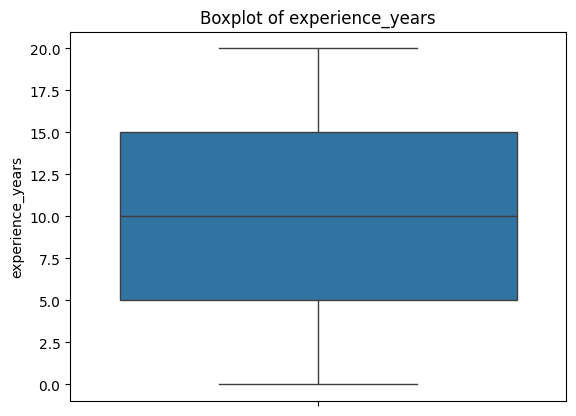

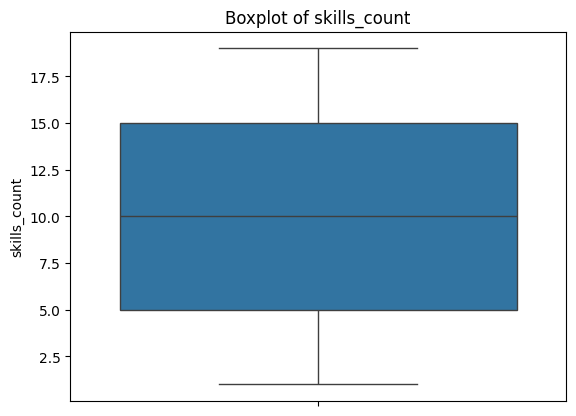

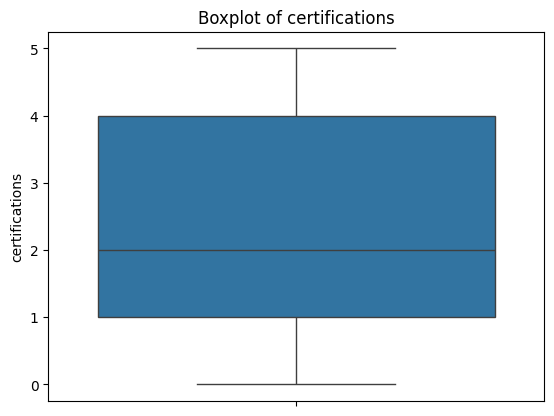

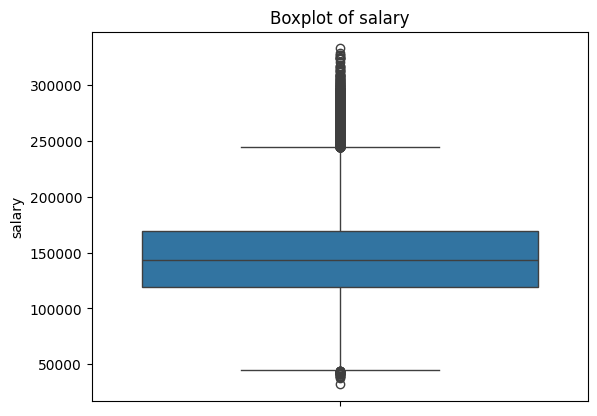

In [20]:
for col in num_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

#### **Checking amount of outliers in salary**

In [21]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["salary"] < lower_bound) | (df["salary"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)

Lower bound: 44157.0
Upper bound: 244693.0
Number of outliers: 2336
Percentage of outliers: 0.9344


Outlier analysis using the IQR method identified approximately 0.93% of salary values as outliers. Given their low proportion and likely representation of high-income roles, these values were retained to preserve real-world distribution characteristics.

### **Normalize numeric columns**

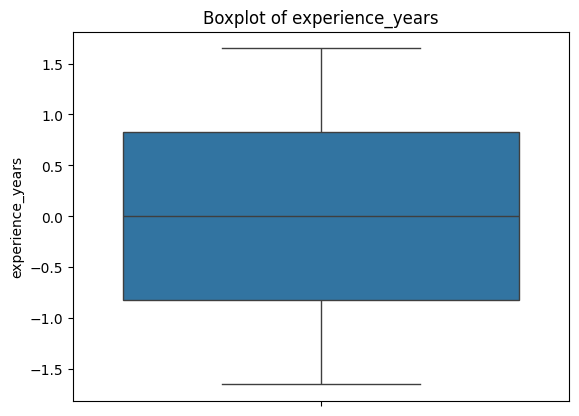

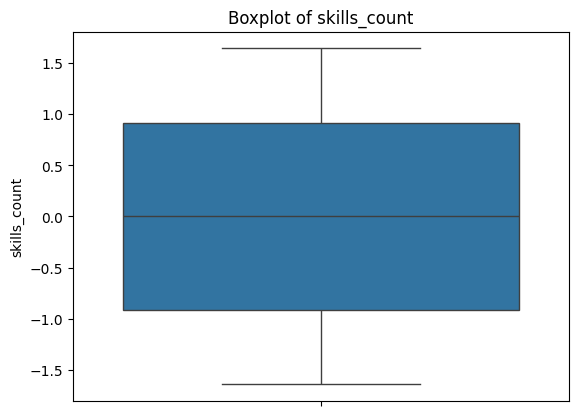

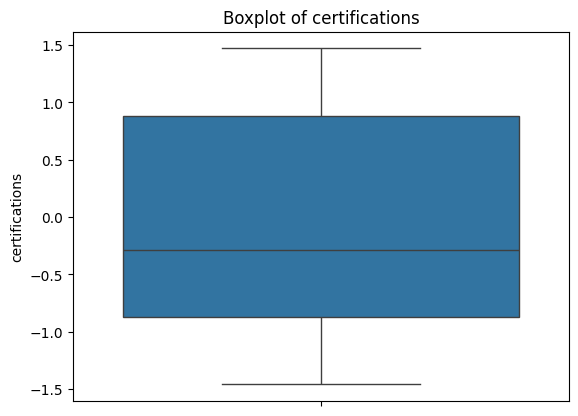

In [22]:
num_cols = ["experience_years", "skills_count", "certifications"]

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

for col in num_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### **Check salary distribution**

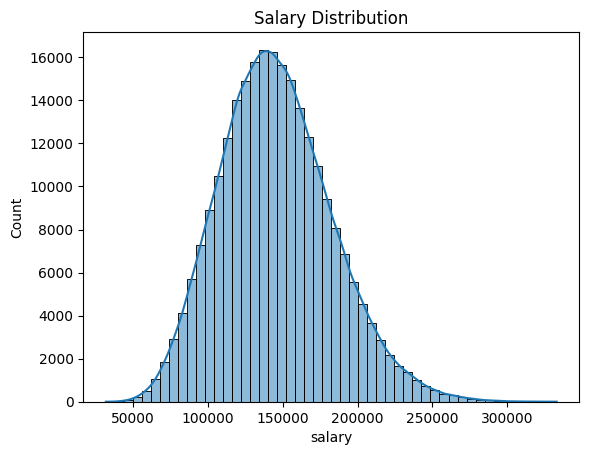

In [23]:
plt.figure()
sns.histplot(df["salary"], bins=50, kde=True)
plt.title("Salary Distribution")
plt.show()

The salary distribution appears approximately normally distributed, indicating that most observations are concentrated around the mean with fewer extreme values on both ends. This suggests a balanced target variable, which is beneficial for regression modelling.

### **Check correlation**

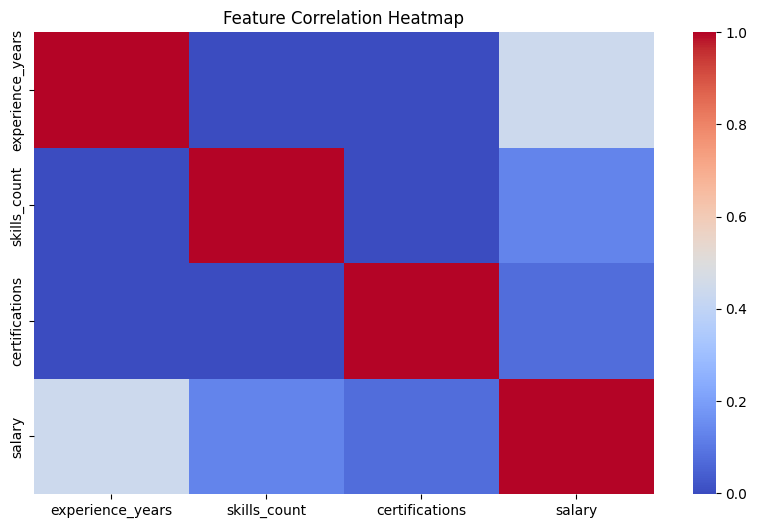

salary              1.000000
experience_years    0.437627
skills_count        0.127300
certifications      0.073819
Name: salary, dtype: float64


In [24]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

print(corr["salary"].sort_values(ascending=False))

Correlation analysis indicates that experience years has the strongest positive relationship with salary (0.44), suggesting it is the most influential feature among the numeric variables. Skills count and certifications show weak correlations, indicating limited linear relationship with salary.

### **One hot for categoric columns**

In [25]:
df = pd.get_dummies(df, columns=cat_cols)

print("New shape after one-hot encoding:")
print(df.shape)

New shape after one-hot encoding:
(250000, 49)
